# ML Basket 4: EWMA Beta Classification (High vs Low Beta)

## Overview
This Jupyter Notebook constructs ML-ready portfolios by classifying factors into HIGH_BETA_EWMA (offensive) and LOW_BETA_EWMA (defensive) categories using exponentially weighted moving average (EWMA) CAPM beta estimates with λ=0.94. It dynamically selects top/bottom 50% of factors by beta, computes equal-weighted returns and turnovers, and generates aggregated baskets for machine learning applications.

## Key Features
- **Beta Estimation**: EWMA CAPM betas (λ=0.94, half-life ≈11 months) for 25 factors.
- **Dynamic Selection**: Monthly rebalancing based on lagged betas (no lookahead bias).
- **Portfolio Construction**: Equal-weighted aggregation of HIGH_BETA_EWMA and LOW_BETA_EWMA portfolios.
- **Turnover Calculation**: Dynamic turnover metrics for transaction cost analysis.
- **Visualization**: Cumulative returns plots with CAGR stats.

## Methodology
1. Load factor excess returns, compute EWMA betas using CAPM.
2. Rank factors by lagged beta, select top/bottom 50% for HIGH_BETA_EWMA/LOW_BETA_EWMA.
3. Aggregate into dynamic portfolios (EW gross returns).
4. Compute turnovers and allocations.
5. Save baskets, allocations; generate plots.

## Dependencies
- Libraries: pandas, numpy, matplotlib, pathlib.
- Data: Signal Parquet files, NYSE P20 benchmark, FF5 factors.
- Environment: macOS with VS Code, Python 3.x.

## Usage
1. Adjust FEATURES_BASELINE if needed.
2. Run cells to load data, compute betas, construct portfolios, and save outputs.
3. Review saved Parquet files and cumulative returns plots.

## Output Files
- **data/ml_data/baskets/basket_4_beta_ewma.parquet**: Parquet with Market, HIGH_BETA_EWMA, LOW_BETA_EWMA returns, and aggregated turnovers.
- **data/ml_data/baskets/allocations/basket_4_allocations.parquet**: Parquet with monthly allocations for HIGH_BETA_EWMA and LOW_BETA_EWMA.

This notebook prepares EWMA beta-based baskets for ML modeling, ensuring dynamic factor selection and academic rigor.

In [1]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 1 : IMPORTS
# ════════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
from pathlib import Path
from typing import Dict, Tuple
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
pd.set_option('display.precision', 4)

print("="*100)
print("📦 NOTEBOOK 4 : EWMA BETA STRATEGY")
print("="*100)
print("✅ Imports loaded")
print("="*100)


📦 NOTEBOOK 4 : EWMA BETA STRATEGY
✅ Imports loaded


In [12]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 2 : LOAD DATA
# ════════════════════════════════════════════════════════════════════════════

print("="*100)
print("📦 CHARGEMENT DES DONNÉES")
print("="*100)

HALFLIFE = 60  # 60 months (5 years) - decay parameter for exponential weighting


FEATURES_BASELINE = {
    # ────────────────────────────────────────────────────────────────────────
    # 1. PROFITABILITY (5 factors) - Theory: Novy-Marx (2013), Fama-French
    # ────────────────────────────────────────────────────────────────────────
    'gross_profitability': 'P10',       # High GP/AT = Strong pricing power (Novy-Marx 2013)
    'operating_profitability': 'P10',   # High OP/AT = Quality (Fama-French 2015)
    'return_on_assets': 'P10',          # High ROA = Profitability (DuPont analysis)
    'change_asset_turnover': 'P10',     # Improving turnover = Efficiency gains
    'change_profit_margin': 'P10',      # Improving margin = Competitive advantage
    
    # ────────────────────────────────────────────────────────────────────────
    # 2. INVESTMENT (6 factors) - Theory: Cooper et al. (2008), Titman et al.
    # ────────────────────────────────────────────────────────────────────────
    'roic': 'P10',                      # HIGH ROIC = Capital efficiency (Brown & Rowe 2007)
    'asset_growth': 'P1',               # LOW asset growth = No empire building (Cooper 2008)
    'investment_capex': 'P1',           # LOW CapEx = Conservative (Titman 2004)
    'capex_inventory_growth': 'P1',     # LOW combined growth = Quality
    'net_share_issues': 'P1',           # LOW dilution = Shareholder-friendly (Pontiff 2008)
    'capex_growth': 'P1',               # LOW CapEx growth = Sustainable
    'sales_growth': 'P1',               # LOW sales growth = Avoid over-expansion (Lakonishok)
    
    # ────────────────────────────────────────────────────────────────────────
    # 3. ACCRUALS & QUALITY (4 factors) - Theory: Sloan (1996), Richardson
    # ────────────────────────────────────────────────────────────────────────
    'working_capital_accruals': 'P1',   # LOW accruals = High earnings quality (Sloan 1996)
    'sales_receivables_gap': 'P10',     # HIGH gap = Real demand (vs channel stuffing)
    'receivables_turnover': 'P10',      # HIGH turnover = Fast collection (credit quality)
    'operating_leverage': 'P10',        # HIGH sales-inventory gap = Real growth
    
    # ────────────────────────────────────────────────────────────────────────
    # 4. LIQUIDITY & SOLVENCY (5 factors) - Theory: Altman Z-score, Piotroski
    # ────────────────────────────────────────────────────────────────────────
    'cash_cushion': 'P10',              # HIGH cash/assets = Financial flexibility
    'debt_capacity': 'P10',             # HIGH debt capacity = Strong tangible base (Almeida 2007)
    'book_leverage': 'P1',              # LOW leverage = Safety (Bhandari 1988 reversal)
    'change_current_ratio': 'P10',      # Improving liquidity = Reduced distress risk
    
    # ────────────────────────────────────────────────────────────────────────
    # 5. OPERATING EFFICIENCY (5 factors) - Theory: Asset pricing, Efficiency
    # ────────────────────────────────────────────────────────────────────────
    'asset_turnover': 'P10',            # HIGH asset turnover = Revenue generation efficiency
    'cash_productivity': 'P10',         # HIGH sales/cash = Efficient cash deployment
    'depreciation_to_ppe': 'P1',        # LOW depreciation = Younger assets (less wear)
    'change_depreciation': 'P1',        # LOW Δ depreciation = Stable asset base
    'tax_income_ratio': 'P10',          # HIGH tax efficiency = Retention quality
}



def load_factor_returns(features_config: Dict[str, str], 
                       data_dir: Path = Path('data/portfolios')) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Load factor returns and compute excess returns for CAPM beta estimation.
    
    Returns:
    --------
    df_returns_EXCESS : pd.DataFrame
        Factor EXCESS returns (R - RF) + Market excess return (for beta calculation)
    df_returns_GROSS : pd.DataFrame
        Factor GROSS returns (for portfolio construction)
    """
    
    returns_dict_excess = {}
    returns_dict_gross = {}
    
    # STEP 1: Load NYSE P20 Benchmark
    nyse_p20_path = Path('data/ml_data/market/market_returns_ew_nys80.parquet')
    
    if not nyse_p20_path.exists():
        print(f"⚠️  NYSE P20 benchmark not found. Please run 06_1 first.")
        raise FileNotFoundError(f"Missing {nyse_p20_path}")
    
    df_nyse_p20 = pd.read_parquet(nyse_p20_path)
    df_nyse_p20['date'] = pd.to_datetime(df_nyse_p20['date'])
    df_nyse_p20 = df_nyse_p20.set_index('date')
    
    market_ret_gross = df_nyse_p20['ret_market_ew'].copy()
    
    # STEP 2: Load RF (Fama-French)
    ff_path = Path('data/factors/ff/FF5.csv')
    df_ff = pd.read_csv(ff_path)
    df_ff['dateff'] = pd.to_datetime(df_ff['dateff'])
    df_ff = df_ff.set_index('dateff')
    
    rf = df_ff['rf']  # Already in decimal
    
    # STEP 3: Load Factor Returns and Calculate Excess
    for factor, leg in features_config.items():
        signal_path = data_dir / f'{factor}_signal.parquet'
        
        if not signal_path.exists():
            continue
        
        signal_df = pd.read_parquet(signal_path)
        signal_df['date'] = pd.to_datetime(signal_df['date'])
        signal_df = signal_df.set_index('date')
        
        if leg == 'P10':
            factor_ret_gross = signal_df['ret_high_ew']
        else:
            factor_ret_gross = signal_df['ret_low_ew']
        
        # GROSS returns (for portfolio construction)
        returns_dict_gross[factor] = factor_ret_gross
        
        # EXCESS returns (for beta calculation)
        common_dates = factor_ret_gross.index.intersection(rf.index)
        factor_ret_excess = factor_ret_gross.loc[common_dates] - rf.loc[common_dates]
        returns_dict_excess[factor] = factor_ret_excess
    
    # STEP 4: Construct DataFrames
    df_returns_gross = pd.DataFrame(returns_dict_gross)
    df_returns_excess = pd.DataFrame(returns_dict_excess)
    
    # Market excess return (for beta calculation)
    common_dates_mkt = market_ret_gross.index.intersection(rf.index)
    market_ret_excess = market_ret_gross.loc[common_dates_mkt] - rf.loc[common_dates_mkt]
    market_ret_excess = market_ret_excess.reindex(df_returns_excess.index)
    
    df_returns_excess.insert(0, 'Market', market_ret_excess)
    
    return df_returns_excess, df_returns_gross

# Load data (EXCESS for beta, GROSS for portfolios)
df_returns_EXCESS, df_returns_GROSS = load_factor_returns(FEATURES_BASELINE)

print(f"\n✅ Data loaded:")
print(f"   • EXCESS returns (for beta): {df_returns_EXCESS.shape}")
print(f"   • GROSS returns (for portfolios): {df_returns_GROSS.shape}")
print(f"   • Period: {df_returns_EXCESS.index.min().date()} → {df_returns_EXCESS.index.max().date()}")

print("\n" + "="*100)

📦 CHARGEMENT DES DONNÉES

✅ Data loaded:
   • EXCESS returns (for beta): (738, 26)
   • GROSS returns (for portfolios): (738, 25)
   • Period: 1963-07-31 → 2024-12-31



In [13]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 3 : EWMA BETA COMPUTATION
# ════════════════════════════════════════════════════════════════════════════

print("="*100)
print("📈 CALCUL DES EWMA BETAS (λ = 0.94)")
print("="*100)

def compute_ewma_beta(factor_returns: pd.Series, 
                     market_returns: pd.Series,
                     lambda_decay: float = 0.94,
                     min_periods: int = 60) -> pd.Series:
    """
    Compute Exponentially Weighted Moving Average (EWMA) beta.
    
    Parameters:
    -----------
    factor_returns : pd.Series
    market_returns : pd.Series
    lambda_decay : float
        Decay factor (0.94 = RiskMetrics standard for monthly data)
    min_periods : int
        Minimum observations before computing beta
    
    Returns:
    --------
    beta_series : pd.Series
        EWMA beta estimates
    
    Formula:
    --------
    β_t = Σ_{s=1}^{t} w_s × (R_factor,s × R_market,s) / Σ_{s=1}^{t} w_s × R²_market,s
    
    where w_s = λ^(t-s) / Σ λ^(t-j)  (normalized exponential weights)
    
    Properties:
    -----------
    • λ = 0.94 → Half-life ≈ 11 months
    • Effective window ≈ 60 months (95% of weight in last 5 years)
    • Recent observations have MORE weight than distant ones
    • Smoother than rolling window (no "cliff effect" when old data drops)
    """
    
    # Align series
    merged = pd.concat([factor_returns, market_returns], axis=1).dropna()
    merged.columns = ['factor', 'market']
    
    if len(merged) < min_periods:
        return pd.Series(np.nan, index=merged.index)
    
    # Compute cross-product and market variance
    cross_product = merged['factor'] * merged['market']
    market_var = merged['market'] ** 2
    
    # Apply EWMA
    ewma_cov = cross_product.ewm(alpha=1-lambda_decay, adjust=False, min_periods=min_periods).mean()
    ewma_var = market_var.ewm(alpha=1-lambda_decay, adjust=False, min_periods=min_periods).mean()
    
    # Beta = EWMA(Cov) / EWMA(Var)
    beta_series = ewma_cov / ewma_var
    
    return beta_series


def compute_all_ewma_betas(df_returns: pd.DataFrame, 
                          lambda_decay: float = 0.94,
                          min_periods: int = 60) -> pd.DataFrame:
    """
    Compute EWMA betas for all factors.
    """
    
    market_ret = df_returns['Market']
    factor_names = [col for col in df_returns.columns if col != 'Market']
    
    betas_dict = {}
    
    print(f"🔄 Computing EWMA betas for {len(factor_names)} factors...")
    print(f"   • Lambda (λ)      : {lambda_decay}")
    print(f"   • Half-life       : {np.log(0.5)/np.log(lambda_decay):.1f} months")
    print(f"   • Min periods     : {min_periods} months")
    print(f"   • Effective window : ~{int(-np.log(0.05)/np.log(lambda_decay))} months (95% weight)")
    
    for factor in factor_names:
        beta = compute_ewma_beta(df_returns[factor], market_ret, lambda_decay, min_periods)
        betas_dict[factor] = beta
    
    df_betas = pd.DataFrame(betas_dict)
    
    return df_betas

📈 CALCUL DES EWMA BETAS (λ = 0.94)


In [16]:
# ════════════════════════════════════════════════════════════════════════════
# COMPUTE EWMA BETAS
# ════════════════════════════════════════════════════════════════════════════

# ✅ EWMA CONFIGURATION
LAMBDA_DECAY = 0.94  # RiskMetrics standard for monthly data (half-life ≈ 11 months)
MIN_PERIODS = 60     # Minimum 60 months before computing beta




# Utilise:
df_betas_ewma = compute_all_ewma_betas(df_returns_EXCESS, lambda_decay=LAMBDA_DECAY, min_periods=MIN_PERIODS)



print(f"\n✅ EWMA betas computed :")
print(f"   • Shape      : {df_betas_ewma.shape}")
print(f"   • Valid from : {df_betas_ewma.dropna(how='all').index.min().date()}")
print(f"   • Missing    : {df_betas_ewma.isnull().sum().sum()}")

print(f"\n📊 Latest betas (sorted) :")
latest_betas = df_betas_ewma.iloc[-1].dropna().sort_values()
print(f"\n   🔽 Lowest (Defensive) :")
print(latest_betas.head(5).to_string())
print(f"\n   🔼 Highest (Offensive) :")
print(latest_betas.tail(5).to_string())

print("\n" + "="*100)

🔄 Computing EWMA betas for 25 factors...
   • Lambda (λ)      : 0.94
   • Half-life       : 11.2 months
   • Min periods     : 60 months
   • Effective window : ~-48 months (95% weight)

✅ EWMA betas computed :
   • Shape      : (732, 25)
   • Valid from : 1968-06-28
   • Missing    : 1487

📊 Latest betas (sorted) :

   🔽 Lowest (Defensive) :
investment_capex     0.8380
cash_productivity    0.9162
cash_cushion         0.9693
tax_income_ratio     0.9725
book_leverage        0.9742

   🔼 Highest (Offensive) :
gross_profitability      1.1444
sales_receivables_gap    1.1621
sales_growth             1.1654
operating_leverage       1.1809
receivables_turnover     1.2289



In [25]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 4 : PORTFOLIO CONSTRUCTION
# ════════════════════════════════════════════════════════════════════════════

print("="*100)
print("🏗️  CONSTRUCTION DES PORTFOLIOS (EWMA BETA)")
print("="*100)

def construct_beta_portfolios(df_returns_EXCESS: pd.DataFrame,
                              df_returns_GROSS: pd.DataFrame,
                              df_betas: pd.DataFrame,
                              top_pct: float = 0.5) -> Tuple[pd.Series, pd.Series, pd.DataFrame]:
    """
    Construct high/low beta portfolios.
    
    Parameters:
    -----------
    df_returns_EXCESS : For context only
    df_returns_GROSS : USED for portfolio returns (GROSS)
    df_betas : Beta estimates (computed from EXCESS returns)
    top_pct : Proportion of factors in each basket
    """
    
    n_factors = len(df_betas.columns)
    n_select = int(n_factors * top_pct)
    
    print(f"🎯 Parameters:")
    print(f"   • Factors per basket: {n_select} ({top_pct*100:.0f}%)")
    
    high_beta_returns = []
    low_beta_returns = []
    high_alloc_list = []
    low_alloc_list = []
    
    df_betas_lagged = df_betas.shift(1)
    dates = df_betas_lagged.dropna(how='all').index
    
    print(f"\n🔄 Constructing portfolios for {len(dates)} months...")
    print(f"   ⚠️  TIMING: Using beta_{{t-1}} (lagged) for formation, ret_t for holding")
    
    for date in dates:
        betas_t_minus_1 = df_betas_lagged.loc[date].dropna()
        
        if len(betas_t_minus_1) < n_select * 2:
            high_beta_returns.append(np.nan)
            low_beta_returns.append(np.nan)
            high_alloc_list.append(pd.Series(0, index=df_betas.columns))
            low_alloc_list.append(pd.Series(0, index=df_betas.columns))
            continue
        
        betas_sorted = betas_t_minus_1.sort_values()
        low_beta_factors = betas_sorted.head(n_select).index.tolist()
        high_beta_factors = betas_sorted.tail(n_select).index.tolist()
        
        if date not in df_returns_GROSS.index:
            high_beta_returns.append(np.nan)
            low_beta_returns.append(np.nan)
            high_alloc_list.append(pd.Series(0, index=df_betas.columns))
            low_alloc_list.append(pd.Series(0, index=df_betas.columns))
            continue
        
        returns_t_GROSS = df_returns_GROSS.loc[date, df_betas.columns]
        
        high_ret = returns_t_GROSS[high_beta_factors].mean()
        low_ret = returns_t_GROSS[low_beta_factors].mean()
        
        high_beta_returns.append(high_ret)
        low_beta_returns.append(low_ret)
        
        high_alloc = pd.Series(0, index=df_betas.columns)
        high_alloc[high_beta_factors] = 1
        high_alloc_list.append(high_alloc)
        
        low_alloc = pd.Series(0, index=df_betas.columns)
        low_alloc[low_beta_factors] = 1
        low_alloc_list.append(low_alloc)
    
    high_beta_ret = pd.Series(high_beta_returns, index=dates, name='HIGH_BETA_EWMA')
    low_beta_ret = pd.Series(low_beta_returns, index=dates, name='LOW_BETA_EWMA')
    
    allocations = pd.concat({
        'HIGH_BETA': pd.DataFrame(high_alloc_list, index=dates),
        'LOW_BETA': pd.DataFrame(low_alloc_list, index=dates)
    }, axis=1)
    
    return high_beta_ret, low_beta_ret, allocations


🏗️  CONSTRUCTION DES PORTFOLIOS (EWMA BETA)


In [26]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 5 : CONSTRUCTION DES PORTFOLIOS + TURNOVER
# ════════════════════════════════════════════════════════════════════════════

print("="*100)
print("🏗️  CONSTRUCTION DES PORTFOLIOS DYNAMIQUES (EWMA BETA)")
print("="*100)

# Appel de la fonction
Portfolio_High_EWMA, Portfolio_Low_EWMA, allocations_ewma = construct_beta_portfolios(
    df_returns_EXCESS,
    df_returns_GROSS,
    df_betas_ewma,
    0.5
)




print(f"\n✅ Portfolios constructed:")
print(f"   • HIGH_BETA_EWMA: {len(Portfolio_High_EWMA.dropna())} months")
print(f"   • LOW_BETA_EWMA: {len(Portfolio_Low_EWMA.dropna())} months")
print(f"   • Valid from: {Portfolio_High_EWMA.dropna().index.min().date()}")

print(f"\n📊 Aperçu des returns:")
print(pd.DataFrame({
    'HIGH_BETA_EWMA': Portfolio_High_EWMA,
    'LOW_BETA_EWMA': Portfolio_Low_EWMA
}).head(20))

# ════════════════════════════════════════════════════════════════════════════
# CALCUL DU TURNOVER
# ════════════════════════════════════════════════════════════════════════════

print("\n" + "="*100)
print("🔄 CALCUL DU TURNOVER")
print("="*100)

def compute_turnover(allocations: pd.DataFrame, basket_name: str) -> pd.Series:
    alloc = allocations[basket_name]
    alloc_shifted = alloc.shift(1)
    changes = (alloc - alloc_shifted).abs()
    turnover = changes.sum(axis=1) / 2
    return turnover

Turnover_High_EWMA = compute_turnover(allocations_ewma, 'HIGH_BETA')
Turnover_Low_EWMA = compute_turnover(allocations_ewma, 'LOW_BETA')

print(f"\n✅ Turnover computed:")
print(f"   • HIGH_BETA: Mean {Turnover_High_EWMA.mean()*100:.2f}%, Annualized {Turnover_High_EWMA.mean()*1200:.0f}%")
print(f"   • LOW_BETA: Mean {Turnover_Low_EWMA.mean()*100:.2f}%, Annualized {Turnover_Low_EWMA.mean()*1200:.0f}%")

print("\n" + "="*100)


🏗️  CONSTRUCTION DES PORTFOLIOS DYNAMIQUES (EWMA BETA)
🎯 Parameters:
   • Factors per basket: 12 (50%)

🔄 Constructing portfolios for 672 months...
   ⚠️  TIMING: Using beta_{t-1} (lagged) for formation, ret_t for holding

✅ Portfolios constructed:
   • HIGH_BETA_EWMA: 672 months
   • LOW_BETA_EWMA: 672 months
   • Valid from: 1968-07-30

📊 Aperçu des returns:
            HIGH_BETA_EWMA  LOW_BETA_EWMA
1968-07-30     -4.7016e-02        -0.0427
1968-08-30      4.1874e-02         0.0406
1968-09-30      7.8645e-02         0.0891
1968-10-31      2.8342e-02         0.0210
1968-11-29      7.7897e-02         0.0671
1968-12-31     -2.5271e-02        -0.0276
1969-01-31     -2.2734e-02        -0.0181
1969-02-28     -7.9752e-02        -0.0731
1969-03-28      2.0749e-02         0.0202
1969-04-30      1.9919e-02         0.0117
1969-05-29     -5.1468e-05         0.0011
1969-06-30     -9.6164e-02        -0.0824
1969-07-31     -9.1029e-02        -0.0755
1969-08-29      9.3937e-02         0.0720
1969-09

In [27]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 6 : EXPORT
# ════════════════════════════════════════════════════════════════════════════

print("="*100)
print("💾 EXPORT DES RÉSULTATS")
print("="*100)

# Reload NYSE P20 GROSS returns for export
nyse_p20_path = Path('data/ml_data/market/market_returns_ew_nys80.parquet')
df_nyse_p20 = pd.read_parquet(nyse_p20_path)
df_nyse_p20['date'] = pd.to_datetime(df_nyse_p20['date'])
df_nyse_p20 = df_nyse_p20.set_index('date')

market_ret_gross = df_nyse_p20['ret_market_ew']

# Align all series on portfolio index (starts 1968-07-30)
common_index = Portfolio_High_EWMA.dropna().index

df_output = pd.DataFrame({
    'Market': market_ret_gross.reindex(common_index),
    'HIGH_BETA_EWMA': Portfolio_High_EWMA.reindex(common_index),
    'LOW_BETA_EWMA': Portfolio_Low_EWMA.reindex(common_index),
    'Turnover_High': Turnover_High_EWMA.reindex(common_index).fillna(0),
    'Turnover_Low': Turnover_Low_EWMA.reindex(common_index).fillna(0)
})

OUTPUT_PATH = Path('data/ml_data/baskets/basket_4_beta_ewma.parquet')
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
df_output.to_parquet(OUTPUT_PATH)

print(f"✅ EXPORT TERMINÉ:")
print(f"   📁 {OUTPUT_PATH}")
print(f"   📊 Shape: {df_output.shape}")
print(f"   📅 Period: {df_output.index.min().date()} → {df_output.index.max().date()}")
print(f"   📊 Months: {len(df_output)}")

# Verify no NaN
print(f"\n📊 Data Quality:")
print(f"   • Market NaN: {df_output['Market'].isna().sum()}")
print(f"   • HIGH_BETA NaN: {df_output['HIGH_BETA_EWMA'].isna().sum()}")
print(f"   • LOW_BETA NaN: {df_output['LOW_BETA_EWMA'].isna().sum()}")

# Performance summary
mean_monthly = df_output[['Market', 'HIGH_BETA_EWMA', 'LOW_BETA_EWMA']].mean()
print(f"\n📈 Mean Monthly Returns:")
print(f"   • Market: {mean_monthly['Market']*100:.4f}% → {mean_monthly['Market']*1200:.2f}% annualized")
print(f"   • HIGH_BETA: {mean_monthly['HIGH_BETA_EWMA']*100:.4f}% → {mean_monthly['HIGH_BETA_EWMA']*1200:.2f}% annualized")
print(f"   • LOW_BETA: {mean_monthly['LOW_BETA_EWMA']*100:.4f}% → {mean_monthly['LOW_BETA_EWMA']*1200:.2f}% annualized")

print("\n" + "="*100)


💾 EXPORT DES RÉSULTATS
✅ EXPORT TERMINÉ:
   📁 data/ml_data/baskets/basket_4_beta_ewma.parquet
   📊 Shape: (672, 5)
   📅 Period: 1968-07-30 → 2024-06-28
   📊 Months: 672

📊 Data Quality:
   • Market NaN: 0
   • HIGH_BETA NaN: 0
   • LOW_BETA NaN: 0

📈 Mean Monthly Returns:
   • Market: 1.1217% → 13.46% annualized
   • HIGH_BETA: 1.2093% → 14.51% annualized
   • LOW_BETA: 1.2336% → 14.80% annualized



In [28]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 6.5 : SAVE ALLOCATIONS (OPTIONAL BUT RECOMMENDED)
# ════════════════════════════════════════════════════════════════════════════

print("="*100)
print("💾 EXPORT DES ALLOCATIONS")
print("="*100)

ALLOC_PATH_EWMA = Path('data/ml_data/baskets/allocations/basket_4_allocations.parquet')
allocations_ewma.to_parquet(ALLOC_PATH_EWMA)

print(f"✅ Allocations sauvegardées :")
print(f"   📁 {ALLOC_PATH_EWMA}")
print(f"   📊 Shape : {allocations_ewma.shape}")

high_stability = (allocations_ewma['HIGH_BETA'].diff() == 0).mean(axis=0).sort_values(ascending=False)
print(f"\n📊 Top 5 facteurs les plus STABLES dans HIGH_BETA (EWMA) :")
print(high_stability.head().to_string())

print("\n" + "="*100)

💾 EXPORT DES ALLOCATIONS
✅ Allocations sauvegardées :
   📁 data/ml_data/baskets/allocations/basket_4_allocations.parquet
   📊 Shape : (672, 50)

📊 Top 5 facteurs les plus STABLES dans HIGH_BETA (EWMA) :
cash_productivity      0.9866
asset_turnover         0.9807
gross_profitability    0.9762
depreciation_to_ppe    0.9717
net_share_issues       0.9613



📈 VISUALISATION


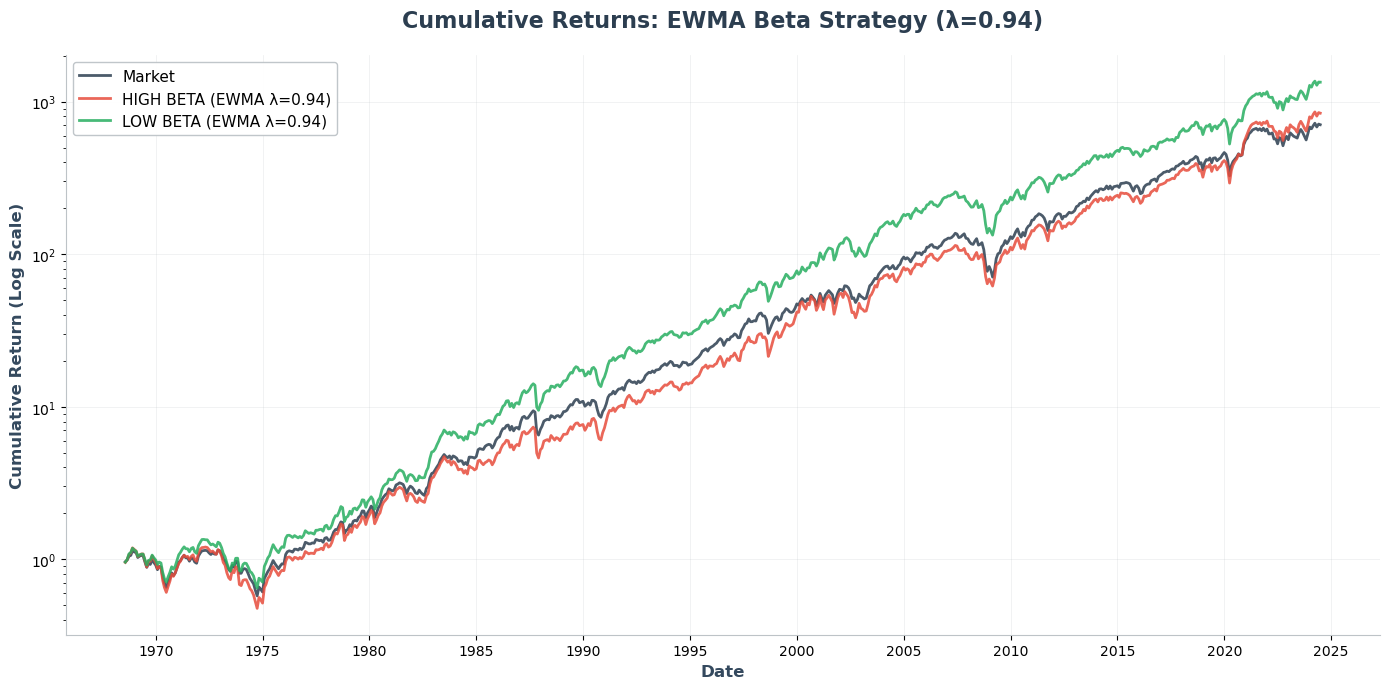


📊 CAGR :
   • HIGH BETA (EWMA) : 12.80% per year
   • LOW BETA (EWMA)  : 13.75% per year

✅ NOTEBOOK 4 TERMINÉ

📌 EXPECTED RESULTS :
   • Turnover : Lower than Rolling (smoother transitions)
   • Performance : Similar to Rolling but less volatile
   • Trade-off : EWMA = Better for transaction costs vs Rolling


In [29]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 7 : VISUALIZATION
# ════════════════════════════════════════════════════════════════════════════

print("="*100)
print("📈 VISUALISATION")
print("="*100)

cumret = (1 + df_output[['Market', 'HIGH_BETA_EWMA', 'LOW_BETA_EWMA']].dropna()).cumprod()

fig, ax = plt.subplots(figsize=(14, 7), facecolor='white')

ax.plot(cumret.index, cumret['Market'], color='#2C3E50', linewidth=2.0, label='Market', alpha=0.85)
ax.plot(cumret.index, cumret['HIGH_BETA_EWMA'], color='#E74C3C', linewidth=2.0, label='HIGH BETA (EWMA λ=0.94)', alpha=0.85)
ax.plot(cumret.index, cumret['LOW_BETA_EWMA'], color='#27AE60', linewidth=2.0, label='LOW BETA (EWMA λ=0.94)', alpha=0.85)

ax.set_title('Cumulative Returns: EWMA Beta Strategy (λ=0.94)', fontsize=16, fontweight='bold', color='#2C3E50', pad=20)
ax.set_xlabel('Date', fontsize=12, fontweight='600', color='#34495E')
ax.set_ylabel('Cumulative Return (Log Scale)', fontsize=12, fontweight='600', color='#34495E')
ax.set_yscale('log')

ax.grid(True, which='major', linestyle='-', linewidth=0.5, color='#BDC3C7', alpha=0.3)
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax.legend(loc='upper left', frameon=True, shadow=False, framealpha=0.95, edgecolor='#BDC3C7', fontsize=11)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#BDC3C7')
ax.spines['bottom'].set_color('#BDC3C7')

plt.tight_layout()
plt.show()

n_years = (cumret.index[-1] - cumret.index[0]).days / 365.25
cagr_high = (cumret['HIGH_BETA_EWMA'].iloc[-1] ** (1/n_years)) - 1
cagr_low = (cumret['LOW_BETA_EWMA'].iloc[-1] ** (1/n_years)) - 1

print(f"\n📊 CAGR :")
print(f"   • HIGH BETA (EWMA) : {cagr_high*100:.2f}% per year")
print(f"   • LOW BETA (EWMA)  : {cagr_low*100:.2f}% per year")

print("\n" + "="*100)
print("✅ NOTEBOOK 4 TERMINÉ")
print("="*100)
print("\n📌 EXPECTED RESULTS :")
print("   • Turnover : Lower than Rolling (smoother transitions)")
print("   • Performance : Similar to Rolling but less volatile")
print("   • Trade-off : EWMA = Better for transaction costs vs Rolling")
print("="*100)